# Appendix figure — toy model: raising vs lowering τ (κ vs C)

Reproduces the appendix figure `newfig-working-1.pdf` (Appendix C) of *Understanding
temperature tuning in energy-based models*.

- **Panels a–f**: two ground-truth gap regimes — *small gap* (κ < C ⇒ raise τ) and
  *large gap* (κ > C ⇒ lower τ) — showing true vs fit probabilities and the τ\* correction.
- **Panel g**: κ(τ=1) and C(τ=1) vs Δ, averaged over replicates.

Data (`newfigdict.jld2`, `kappa_C_plot_dict.jld2`) ships in this folder.


In [1]:
using DrWatson
@quickactivate "temp-tune"

# PyPlot + Printf must load before the src includes: they use the L"..." and @printf
# macros, which expand at include time. The src files assume the caller imports these.
using JLD2, PyPlot, Statistics, Printf

# Reuse temp-tune source: plotting/paper style + toy-model helpers
include(srcdir("matplotlib_helpers.jl"))   # set_size_for_paper, set_plot_style_for_paper, setup_notebook_for_paper, using_Py
include(srcdir("two_level_toy_model.jl"))  # olive_drab_rgba, get_p_toy, get_dkl

setup_notebook_for_paper()
using_Py(true)

In [2]:
# --- Toy-model κ/C helpers (ported from proteins/temp_analysis/simple_toy_model.ipynb) ---

# Bar color used by the panels (matches the source; it lives as a local inside a src
# plotting function, so we define it here at accessible scope).
const olive_drab_rgba = (matplotlib.colors.to_rgba("goldenrod")[1:3]..., 0.3)

"κ(τ) = (1/Tp)(1/τ) Cov_{q_τ}(Δ L, Δ̂ L̂), with q_τ(i) ∝ exp(-Δ̂ L̂_i / τ)."
function get_kappa(L::AbstractVector{<:Real}, Lhat::AbstractVector{<:Real},
                   Delta::Real, Deltahat::Real, tau::Real; Tp::Real=1.0)
    @assert length(L) == length(Lhat) "L and Lhat must have same length"
    @assert tau > 0 && Tp > 0 "tau and Tp must be positive"
    Ep = Delta    .* L
    Eq = Deltahat .* Lhat
    w = @. exp(-Eq / tau); q = w ./ sum(w)
    E_Ep   = sum(q .* Ep)
    E_Eq   = sum(q .* Eq)
    E_prod = sum(q .* (Ep .* Eq))
    cov_Ep_Eq = E_prod - E_Ep * E_Eq
    return (1 / Tp) * (1 / tau) * cov_Ep_Eq
end

"Reduced-units heat capacity C(τ) = Var_{q_τ}(E_q)/τ², E_q(i)=Δ̂ L̂_i."
function get_heat_capacity(Lhat::AbstractVector{<:Real}, Deltahat::Real, tau::Real)
    @assert tau > 0 "tau must be positive"
    Eq = Deltahat .* Lhat
    w  = @. exp(-Eq / tau); q = w ./ sum(w)
    μ   = sum(q .* Eq)
    var = sum(q .* (Eq .- μ).^2)
    return var / (tau^2)
end

"Find τ* minimizing D_KL(q̂_{τ}||p) by a fine τ sweep; returns (τ*, p̂_{τ*})."
function get_p_fit_star_toy(true_probs, delta_fit, L_hat)
    tau_fits = collect(0.1:0.001:5)
    p_fit_mod = similar(true_probs)
    dklss = Float64[]
    for tt in tau_fits
        p_fit_mod .= get_p_toy(L_hat, delta_fit / tt)
        push!(dklss, get_dkl(p_fit_mod, true_probs))
    end
    _, idx = findmin(dklss)
    tau_star = tau_fits[idx]
    return tau_star, get_p_toy(L_hat, delta_fit / tau_star)
end

"Panel-plotter for one gap regime: true vs fit probabilities (+ optional sample freqs)."
function toy_fit_true_probs(ax, true_probs, pfit, freqs, m_to_l, N_states;
                            freqs_off=false, leg_on=true, true_off=false)
    if !true_off
        ax.bar(collect(1:N_states), true_probs[m_to_l], label="true",
               color=olive_drab_rgba, ec="goldenrod", lw=1.)
    end
    ax.bar(collect(1:N_states), pfit[m_to_l], alpha=0.5,
           color="black", label="fit", ec="black", lw=1.)
    if !freqs_off
        ax.plot(collect(1:N_states), freqs[m_to_l], linewidth=0, marker="o",
                markersize=5, color="black", markeredgecolor="k", label="samples")
        for (x, f) in zip(collect(1:N_states), freqs[m_to_l])
            ax.vlines(x, 0, f, linestyle="--", color="k")
        end
    end
    ax.set_xticks(collect(5:5:15))
    ax.spines["right"].set_visible(false)
    ax.spines["top"].set_visible(false)
    leg_on && ax.legend(frameon=false, loc="lower right")
    ax.set_xlabel("state index")
    ax.set_ylabel("probability")
    ax.tick_params(axis="both", which="major")
end

"Panel (g): κ(τ=1) and C(τ=1) vs Δ across replicates (res.kappa, res.C are (nΔ × nrep))."
function kappa_and_C_plot(ax, res, Delta_grid)
    κ_mean = mean(res.kappa, dims=2)[:]
    C_mean = mean(res.C,     dims=2)[:]
    ax.plot(Delta_grid, κ_mean, "k.", ls="none", markeredgewidth=0.6, zorder=50,
        label=L"\kappa(\tau=1) =\text{Cov} (E_\text{true}, \hat E)_{\hat{q}_{\tau=1} }")
    ax.plot(Delta_grid, C_mean, "k.", ls="none", markeredgewidth=0.6, mfc="white",
        label=L"C(\tau=1) =\text{Var} (\hat E)_{\hat{q}_{\tau=1} }")
    ylimcurr = ax.get_ylim()
    ax.vlines(6., -0.1, 0.7, zorder=-50, color="k", alpha=0.05)
    ax.set_ylim(ylimcurr)
    handles, labels = ax.get_legend_handles_labels()
    new_label = L"\frac{\partial}{\partial \tau} D_{\text{KL}}(\hat q_\tau || p) \  =\kappa(\tau=1)-C(\tau=1)"
    new_patch = matplotlib.patches.Patch(color="white", label=new_label)
    pushfirst!(handles, new_patch); pushfirst!(labels, new_label)
    ax.legend(handles=handles, labels=labels, loc=(0.0, 0.62),
              labelspacing=0.1, frameon=false, handletextpad=0.2, handlelength=0.8)
    ax.text(3.7, 0.05, L"\kappa<C" * ", raise " * L"\tau")
    ax.text(6.4, 0.05, L"\kappa>C" * ", lower " * L"\tau")
    return nothing
end

kappa_and_C_plot

In [3]:
# Load the committed summary dicts (in this folder).
newfigdict = jldopen(f -> f["data"], joinpath(@__DIR__, "newfigdict.jld2"), "r")

res, Delta_grid = jldopen(joinpath(@__DIR__, "kappa_C_plot_dict.jld2"), "r") do f
    f["res"], f["Delta_grid"]
end

@show collect(keys(newfigdict));
@show typeof(res) size(res.kappa) length(Delta_grid);

collect(keys(newfigdict)) = Any["large gap", "small gap"]
typeof(res) = NamedTuple{(:kappa, :C), Tuple{Matrix{Float64}, Matrix{Float64}}}
size(res.kappa) = (57, 200)
length(Delta_grid) = 57


In [ ]:
set_plot_style_for_paper()

saved reproduced panels to: /Users/pfields/Git/temp-tune/plots/supplemental/newfig_reproduced.svg


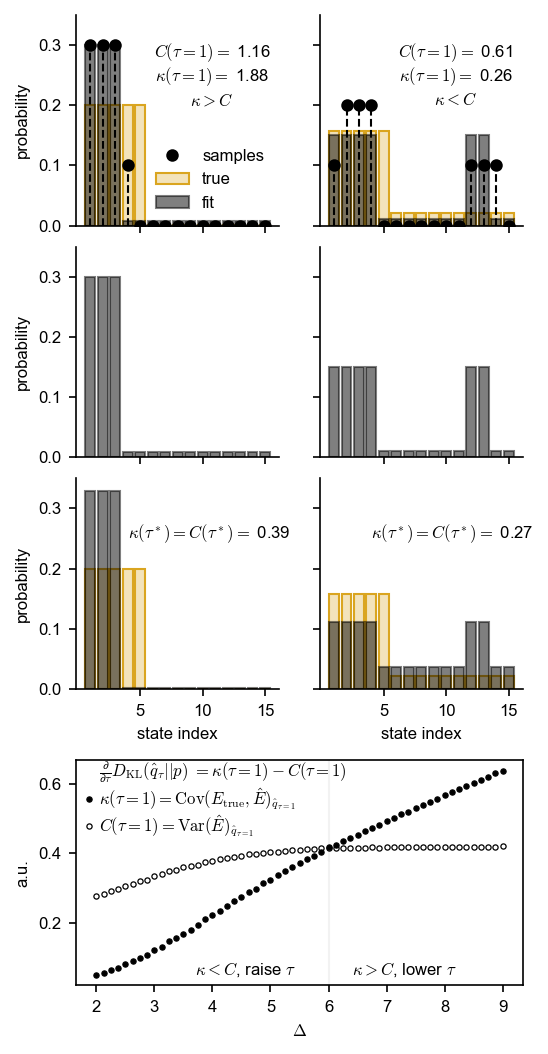

In [7]:
# Reproduce appendix figure `newfig-working-1.pdf` (Appendix C, toy model).
# Panels a–f: two gap regimes ("small gap": κ<C, raise τ; "large gap": κ>C, lower τ).
# Panel g: κ(τ=1), C(τ=1) vs Δ averaged over replicates.
# set_plot_style_for_paper(label_pt=8, tick_pt=8, legend_pt=8)

fig = plt.figure(figsize=set_size_for_paper(1, 2.), dpi=150)
gs_main   = fig.add_gridspec(3, 2, left=0.125, right=1., bottom=0.34, top=1., hspace=0.1)
gs_bottom = fig.add_gridspec(1, 1, left=0.125, right=1., bottom=0.05, top=0.27)

ax1 = fig.add_subplot(gs_main[0, 0]); ax4 = fig.add_subplot(gs_main[0, 1])
ax2 = fig.add_subplot(gs_main[1, 0]); ax5 = fig.add_subplot(gs_main[1, 1])
ax3 = fig.add_subplot(gs_main[2, 0]); ax6 = fig.add_subplot(gs_main[2, 1])
ax7 = fig.add_subplot(gs_bottom[0, 0])

axss1_6 = [ax1, ax2, ax3, ax4, ax5, ax6]
for a in axss1_6
    a.sharey(ax1)
end

for k in ["small gap", "large gap"]
    freqs      = newfigdict[k]["freqs"]
    true_probs = newfigdict[k]["true_probs"]
    pfit       = newfigdict[k]["pfit"]
    delta_fit  = newfigdict[k]["delta-hat"]
    L_hat      = newfigdict[k]["L-hat"]
    L          = newfigdict[k]["L-true"]
    delta_true = newfigdict[k]["Delta_true"]
    N_states   = length(pfit)
    m_to_l     = newfigdict[k]["m_to_l"]

    axss   = k == "small gap" ? [ax1, ax2, ax3] : [ax4, ax5, ax6]
    leg_on = k == "large gap"

    C1_fit = get_heat_capacity(L_hat, delta_fit, 1.)
    kappa1 = get_kappa(L, L_hat, delta_true, delta_fit, 1.)
    axss[2].text(9, 0.2, k == "small gap" ? L"\kappa < C" : L"\kappa > C")
    fdsfv = 0.04
    axss[2].text(6.1, 0.32 - fdsfv, L"C(\tau=1) = \ " * "$(round(C1_fit, digits=2))")
    axss[2].text(6.2, 0.28 - fdsfv, L"\kappa({\tau=1}) = \ " * "$(round(kappa1, digits=2))")

    toy_fit_true_probs(axss[2], true_probs, pfit, freqs, m_to_l, N_states; leg_on=leg_on)
    toy_fit_true_probs(axss[3], true_probs, pfit, freqs, m_to_l, N_states;
                       freqs_off=true, leg_on=false, true_off=true)

    tau_star, p_fit_mod = get_p_fit_star_toy(true_probs, delta_fit, L_hat)
    toy_fit_true_probs(axss[1], true_probs, p_fit_mod, freqs, m_to_l, N_states;
                       freqs_off=true, leg_on=false)

    Copt_fit = get_heat_capacity(L_hat, delta_fit, tau_star)
    axss[1].text(4., 0.25, L"\kappa(\tau^*) = C(\tau^*) = \ " * "$(round(Copt_fit, digits=2))")
end

ax1.set_ylim(0., 0.35)
for (i, a) in enumerate(axss1_6)
    if i <= 3
        a.tick_params(labelleft=false); a.set_ylabel("")
    end
    ((i == 1) || (i == 4)) && continue
    a.tick_params(labelbottom=false); a.set_xlabel("")
end

kappa_and_C_plot(ax7, res, Delta_grid)
ax7.set_xlabel(L"\Delta")
ax7.set_ylabel("a.u.")

mkpath(plotsdir("supplemental"))
outpath = plotsdir("supplemental", "newfig_reproduced.svg")
savefig(outpath, bbox_inches="tight")
println("saved reproduced panels to: ", outpath)
# fig